In [1]:
!git clone https://github.com/niaz1971/COTTON_LEAF_DISEASE_DATASET.git

Cloning into 'COTTON_LEAF_DISEASE_DATASET'...
remote: Enumerating objects: 151, done.
remote: Counting objects: 100% (151/151), done.
remote: Compressing objects: 100% (145/145), done.
remote: Total 151 (delta 53), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (151/151), 163.62 MiB | 16.26 MiB/s, done.
Resolving deltas: 100% (53/53), done.
Updating files: 100% (24/24), done.


In [2]:
cd COTTON_LEAF_DISEASE_DATASET

/content/COTTON_LEAF_DISEASE_DATASET


In [3]:
!pip install lime kaggle
# Step 2: Set up Kaggle API for dataset download
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
# Step 3: Download and unzip malaria cell images dataset
!kaggle datasets download -d pantho12/sar-cld-2024-dataset-for-cotton-leaf
!unzip -q sar-cld-2024-dataset-for-cotton-leaf.zip
!rm sar-cld-2024-dataset-for-cotton-leaf.zip

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283913 sha256=910b6521834363d6a7ad136505a65eded0a97111f1191f40d814a7462cdab075
  Stored in directory: /root/.cache/pip/wheels/7c/04/5c/157dc9106512a6c7a30653ec064490c94a49e0fc8f63d19ab9
Successfully built lime
Dataset URL: https://www.kaggle.com/datasets/pantho12/sar-cld-2024-dataset-for-cotton-leaf
License(s): Attribution 4.0 International (CC BY 4.0)
100% 1.46G/1.46G [00:10<00:00, 150MB/s]



In [4]:
!ls

 1_EFFICIENTNET.ipynb
 AZHAR_PAPER_MODELS_WITH_DIFFERENT_SEEDS
 EFFICIENTNET.ipynb
 INCEPTIONV3.ipynb
 kaggle.json
 MOBILENET.ipynb
 MODEL_SEND_BY_MUDASAR
 RESNET101.ipynb
 RESNET152.ipynb
 RESNET50.ipynb
'SAR-CLD-2024 A Comprehensive Dataset for Cotton Leaf Disease Detection'
 SHUFFLENET.ipynb
 VGG16.ipynb
 VGG19.ipynb
 XCEPTION.ipynb


In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import warnings

# SUPPRESS ALL WARNINGS (simplest fix)
warnings.filterwarnings('ignore')

# Set random seeds
tf.random.set_seed(44)
np.random.seed(44)
print("✅ TensorFlow:", tf.__version__)

# =====================================================================
# UPDATED DATASET PATHS FOR SAR-CLD-2024
# =====================================================================
# Adjust the root folder name based on where you extracted the zip file.
# If running directly inside a Kaggle Notebook, use: "/kaggle/input/sar-cld-2024-dataset-for-cotton-leaf"
base_dataset_path = "SAR-CLD-2024 A Comprehensive Dataset for Cotton Leaf Disease Detection"

# Mapping to Augmented for training/validation, and Original for testing
augmented_path = os.path.join(base_dataset_path, "Augmented Dataset", "Augmented Dataset")
original_path = os.path.join(base_dataset_path, "Original Dataset", "Original Dataset")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2, # Splitting augmented data for training and validation
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Load datasets
train_generator = train_datagen.flow_from_directory(
    augmented_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    augmented_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    original_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

✅ TensorFlow: 2.20.0
Found 5600 images belonging to 7 classes.
Found 1400 images belonging to 7 classes.
Found 2137 images belonging to 7 classes.


In [6]:
# Dataset info
class_names = list(train_generator.class_indices.keys())
print(f"\n✅ Dataset loaded:")
print(f"Train: {train_generator.samples}, Val: {val_generator.samples}, Test: {test_generator.samples}")
print(f"Classes: {class_names}")


✅ Dataset loaded:
Train: 5600, Val: 1400, Test: 2137
Classes: ['Bacterial Blight', 'Curl Virus', 'Healthy Leaf', 'Herbicide Growth Damage', 'Leaf Hopper Jassids', 'Leaf Redding', 'Leaf Variegation']


In [7]:
# Model (VGG16)
def create_model(num_classes):
    base_model = tf.keras.applications.VGG16(
        input_shape=(224, 224, 3), include_top=False, weights='imagenet'
    )
    base_model.trainable = False

    model = tf.keras.Sequential([
        base_model,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    return model

model = create_model(len(class_names))
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()
print("\nModel ready!")

# Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_accuracy', factor=0.2, patience=3, min_lr=1e-7),
    tf.keras.callbacks.ModelCheckpoint('best_cotton_model.h5', save_best_only=True, monitor='val_accuracy')
]

# TRAIN
print("\n🚀 Training starts NOW...")
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=30, ################30
    validation_data=val_generator,
    validation_steps=val_generator.samples // BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,781,255 (56.39 MB)

 Trainable params: 66,567 (260.03 KB)

...

175/175 ━━━━━━━━━━━━━━━━━━━━ 155s 766ms/step - accuracy: 0.1787 - loss: 1.9988 - val_accuracy: 0.2994 - val_loss: 1.8647 - learning_rate: 1.0000e-04
Epoch 2/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 591ms/step - accuracy: 0.2250 - loss: 1.8832

175/175 ━━━━━━━━━━━━━━━━━━━━ 130s 740ms/step - accuracy: 0.2477 - loss: 1.8544 - val_accuracy: 0.4317 - val_loss: 1.7798 - learning_rate: 1.0000e-04
Epoch 3/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 591ms/step - accuracy: 0.3135 - loss: 1.7773

175/175 ━━━━━━━━━━━━━━━━━━━━ 129s 739ms/step - accuracy: 0.3350 - loss: 1.7506 - val_accuracy: 0.4956 - val_loss: 1.7004 - learning_rate: 1.0000e-04
Epoch 4/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 591ms/step - accuracy: 0.3648 - loss: 1.6945

175/175 ━━━━━━━━━━━━━━━━━━━━ 129s 738ms/step - accuracy: 0.3796 - loss: 1.6730 - val_accuracy: 0.5007 - val_loss: 1.6373 - learning_rate: 1.0000e-04
Epoch 5/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 595ms/step - accuracy: 0.4329 - loss: 1.6081

175/175 ━━━━━━━━━━━━━━━━━━━━ 143s 742ms/step - accuracy: 0.4343 - loss: 1.5851 - val_accuracy: 0.5247 - val_loss: 1.5606 - learning_rate: 1.0000e-04
Epoch 6/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 129s 739ms/step - accuracy: 0.4613 - loss: 1.5170 - val_accuracy: 0.4956 - val_loss: 1.5065 - learning_rate: 1.0000e-04
Epoch 7/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 130s 736ms/step - accuracy: 0.4818 - loss: 1.4584 - val_accuracy: 0.5051 - val_loss: 1.4692 - learning_rate: 1.0000e-04
Epoch 8/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 129s 739ms/step - accuracy: 0.5038 - loss: 1.4059 - val_accuracy: 0.5007 - val_loss: 1.4331 - learning_rate: 1.0000e-04
Epoch 9/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 142s 740ms/step - accuracy: 0.5145 - loss: 1.3728 - val_accuracy: 0.5145 - val_loss: 1.4071 - learning_rate: 2.0000e-05
Epoch 10/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 140s 726ms/step - accuracy: 0.5234 - loss: 1.3617 - val_accuracy: 0.5203 - val_loss: 1.3971 - learning_rate: 2.0000e-05


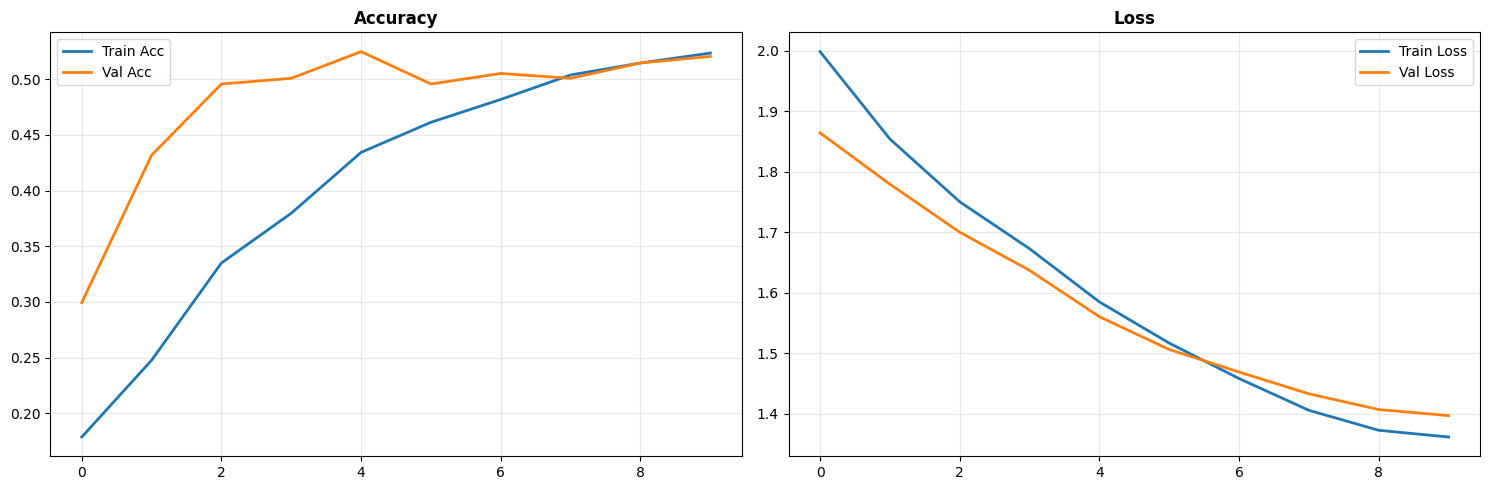


=== TEST RESULTS ===
67/67 ━━━━━━━━━━━━━━━━━━━━ 26s 381ms/step - accuracy: 0.5938 - loss: 1.4538
Test Accuracy: 0.5938
67/67 ━━━━━━━━━━━━━━━━━━━━ 15s 216ms/step

Classification Report:
                         precision    recall  f1-score   support

       Bacterial Blight       0.46      0.66      0.54       250
             Curl Virus       0.69      0.47      0.56       431
           Healthy Leaf       0.34      0.52      0.41       257
Herbicide Growth Damage       0.93      0.96      0.94       280
    Leaf Hopper Jassids       0.37      0.44      0.40       225
           Leaf Redding       0.76      0.51      0.61       578
       Leaf Variegation       0.69      0.92      0.79       116

               accuracy                           0.59      2137
              macro avg       0.61      0.64      0.61      2137
           weighted avg       0.64      0.59      0.60      2137



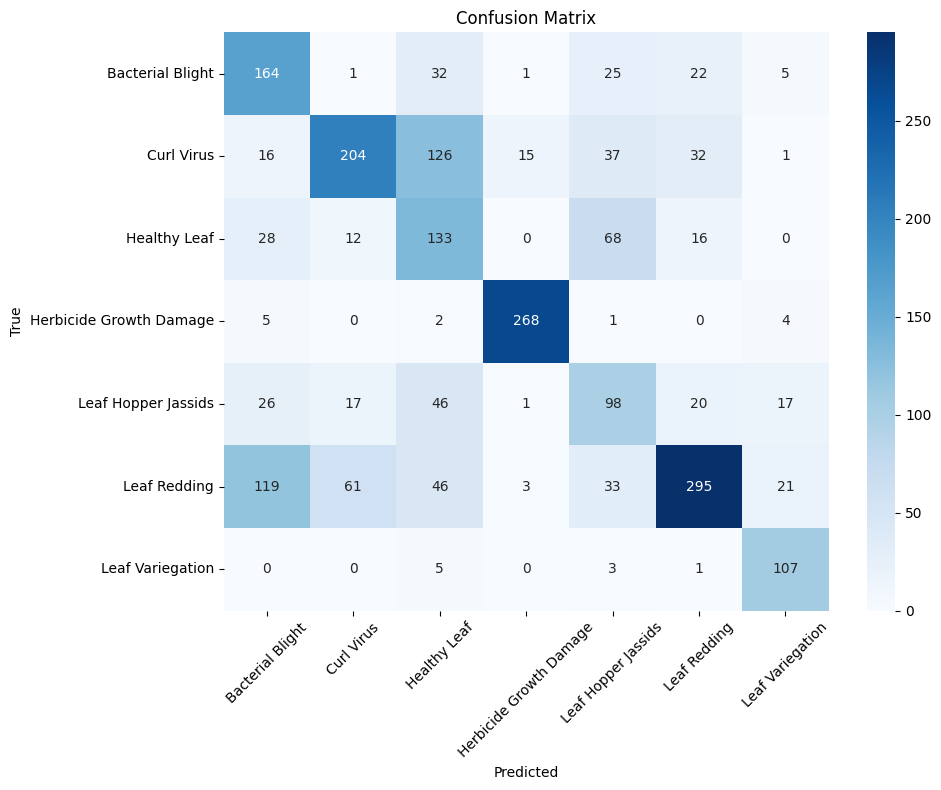


✅ COMPLETE! Models saved.


In [8]:
# Plotting function
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    ax1.plot(history.history['accuracy'], label='Train Acc', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Val Acc', linewidth=2)
    ax1.set_title('Accuracy', fontweight='bold')
    ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(history.history['loss'], label='Train Loss', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    ax2.set_title('Loss', fontweight='bold')
    ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_training_history(history)

# Test evaluation
print("\n=== TEST RESULTS ===")
test_generator.reset()
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f"Test Accuracy: {test_acc:.4f}")

# Classification report & confusion matrix
test_generator.reset()
predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes

print("\nClassification Report:")
print(classification_report(true_classes, predicted_classes, target_names=class_names))

plt.figure(figsize=(10, 8))
cm = confusion_matrix(true_classes, predicted_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Save models
model.save('cotton_disease_final.h5')
print("\n✅ COMPLETE! Models saved.")

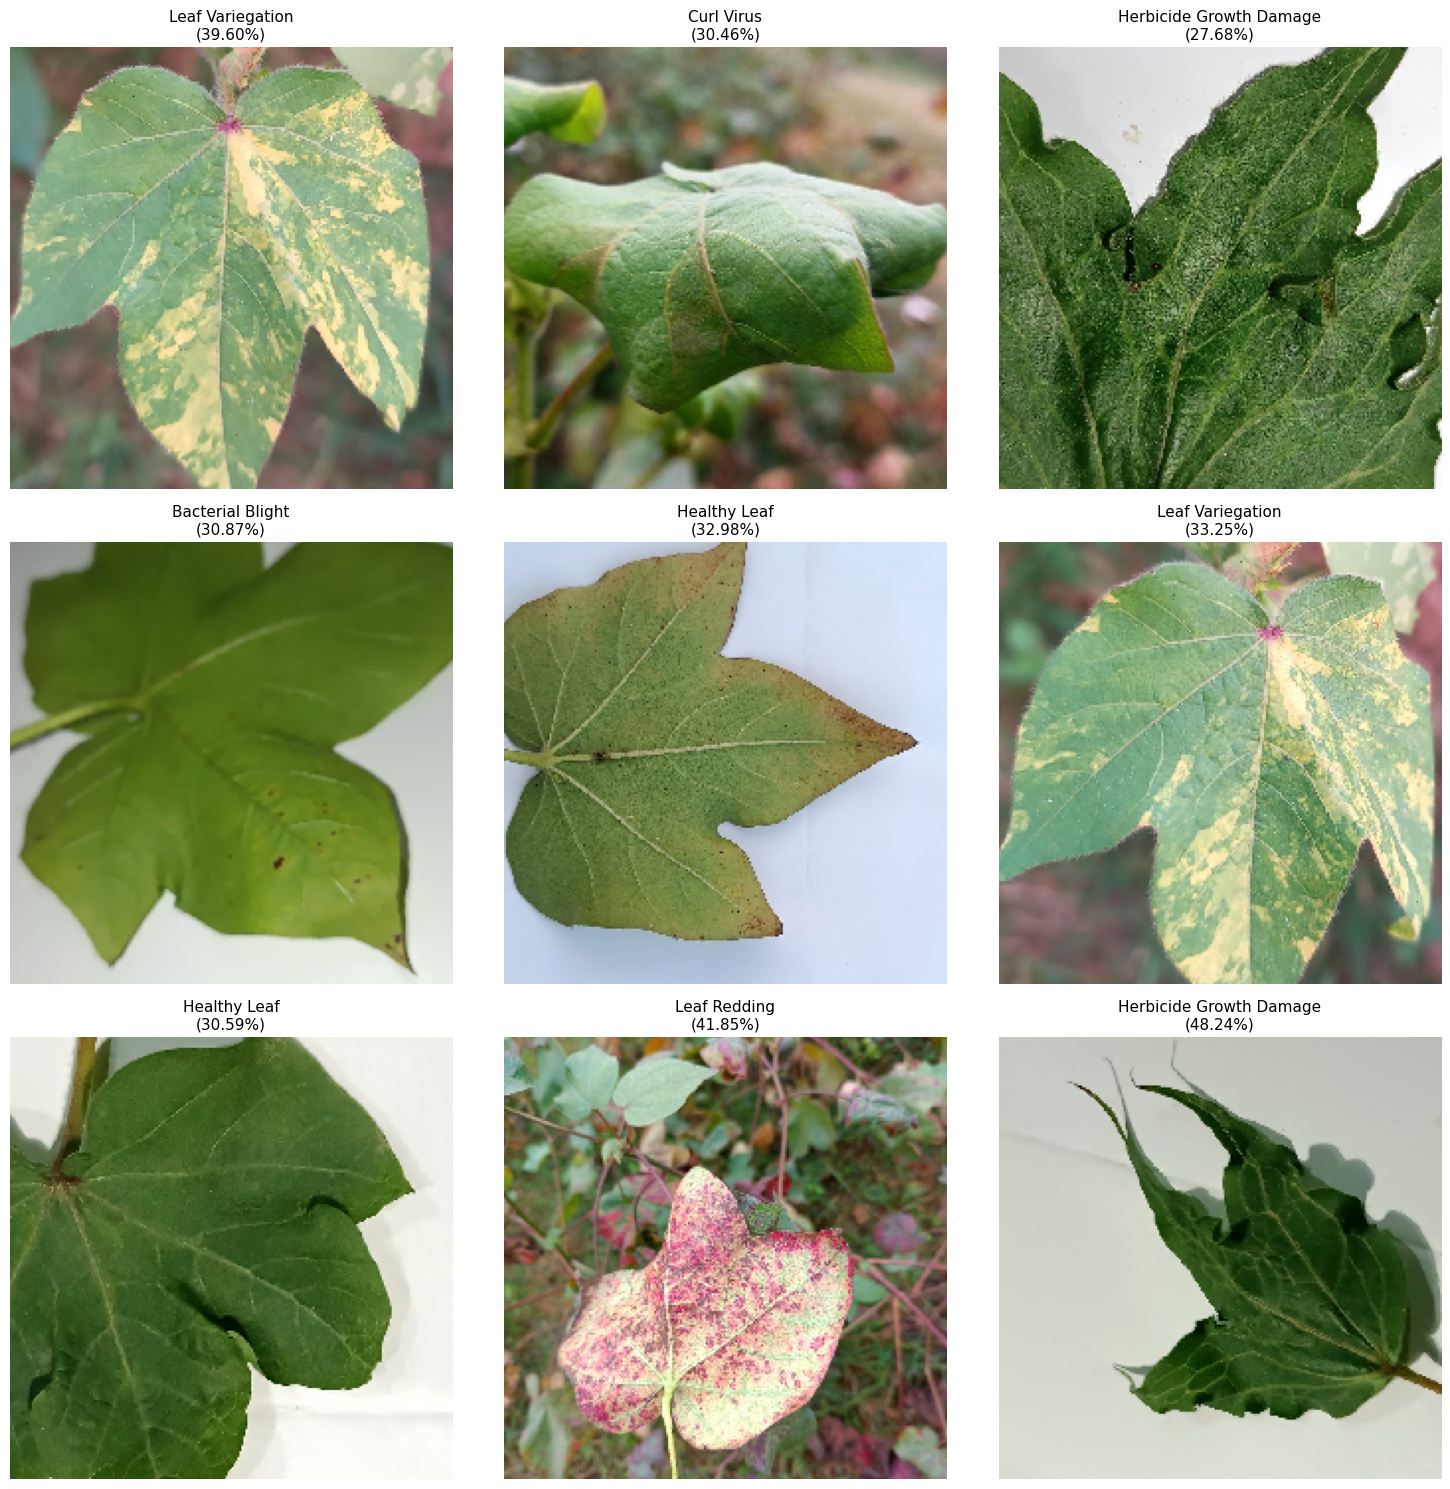

Prediction functions are ready to use!


In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
import random

# Load your trained model
model = load_model('best_cotton_model.h5')

# =====================================================================
# UPDATED CLASS NAMES FOR THE NEW DATASET
# =====================================================================
class_names = [
    'Bacterial Blight',
    'Curl Virus',
    'Healthy Leaf',
    'Herbicide Growth Damage',
    'Leaf Hopper Jassids',
    'Leaf Redding',
    'Leaf Variegation'
]

# Function to predict and display an image
def predict_and_display(img_path, model, class_names):
    # Load and preprocess the image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0  # Normalize like in training

    # Make prediction
    prediction = model.predict(img_array)
    predicted_class = np.argmax(prediction[0])
    confidence = np.max(prediction[0])

    # Get all class probabilities
    class_probabilities = {class_names[i]: float(prediction[0][i]) for i in range(len(class_names))}

    # Sort by probability
    sorted_probs = dict(sorted(class_probabilities.items(), key=lambda item: item[1], reverse=True))

    # Display the image with prediction
    plt.figure(figsize=(10, 8))

    # Show image
    plt.subplot(2, 1, 1)
    plt.imshow(img)
    plt.title(f'Predicted: {class_names[predicted_class]} (Confidence: {confidence:.2%})')
    plt.axis('off')

    # Show probabilities as bar chart
    plt.subplot(2, 1, 2)
    colors = ['green' if c == class_names[predicted_class] else 'blue' for c in sorted_probs.keys()]
    plt.barh(range(len(sorted_probs)), list(sorted_probs.values()), color=colors)
    plt.yticks(range(len(sorted_probs)), list(sorted_probs.keys()))
    plt.xlabel('Probability')
    plt.title('Class Probabilities')
    plt.gca().invert_yaxis()  # Invert y-axis to keep highest probability on top
    plt.tight_layout()
    plt.show()

    return class_names[predicted_class], confidence, class_probabilities

# Function to display multiple predictions in a grid
def display_predictions_grid(image_paths, model, class_names, grid_size=(3, 3)):
    fig, axes = plt.subplots(grid_size[0], grid_size[1], figsize=(15, 15))
    axes = axes.ravel()

    for i, img_path in enumerate(image_paths[:grid_size[0]*grid_size[1]]):
        # Load and preprocess the image
        img = image.load_img(img_path, target_size=(224, 224))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array /= 255.0

        # Make prediction
        prediction = model.predict(img_array, verbose=0)
        predicted_class = np.argmax(prediction[0])
        confidence = np.max(prediction[0])

        # Display the image with prediction
        axes[i].imshow(img)
        axes[i].set_title(f'{class_names[predicted_class]}\n({confidence:.2%})', fontsize=11)
        axes[i].axis('off')

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Function to get random samples from a directory
def get_random_samples(directory, num_samples=9):
    all_images = []
    for root, dirs, files in os.walk(directory):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                all_images.append(os.path.join(root, file))

    return random.sample(all_images, min(num_samples, len(all_images)))

# Example usage
if __name__ == "__main__":
    # =====================================================================
    # UPDATED SAMPLE DIRECTORY
    # =====================================================================
    # Points to the baseline folder from your new dataset structure
    sample_directory = os.path.join(
        "SAR-CLD-2024 A Comprehensive Dataset for Cotton Leaf Disease Detection",
        "Original Dataset",
        "Original Dataset"
    )

    # Alternative context: If testing single images explicitly, uncomment below lines
    # test_image_path = "path_to_some_leaf_image.jpg"
    # predict_and_display(test_image_path, model, class_names)

    # Option: Display multiple random images from the dataset in a grid
    if os.path.exists(sample_directory):
        sample_images = get_random_samples(sample_directory, 9)
        display_predictions_grid(sample_images, model, class_names, grid_size=(3, 3))
    else:
        print(f"⚠️ Directory not found at: {sample_directory}. Please double check path configurations.")

    print("Prediction functions are ready to use!")

67/67 ━━━━━━━━━━━━━━━━━━━━ 15s 215ms/step
67/67 ━━━━━━━━━━━━━━━━━━━━ 14s 208ms/step
Total test samples: 2137
Misclassified samples: 868
Accuracy: 59.38%


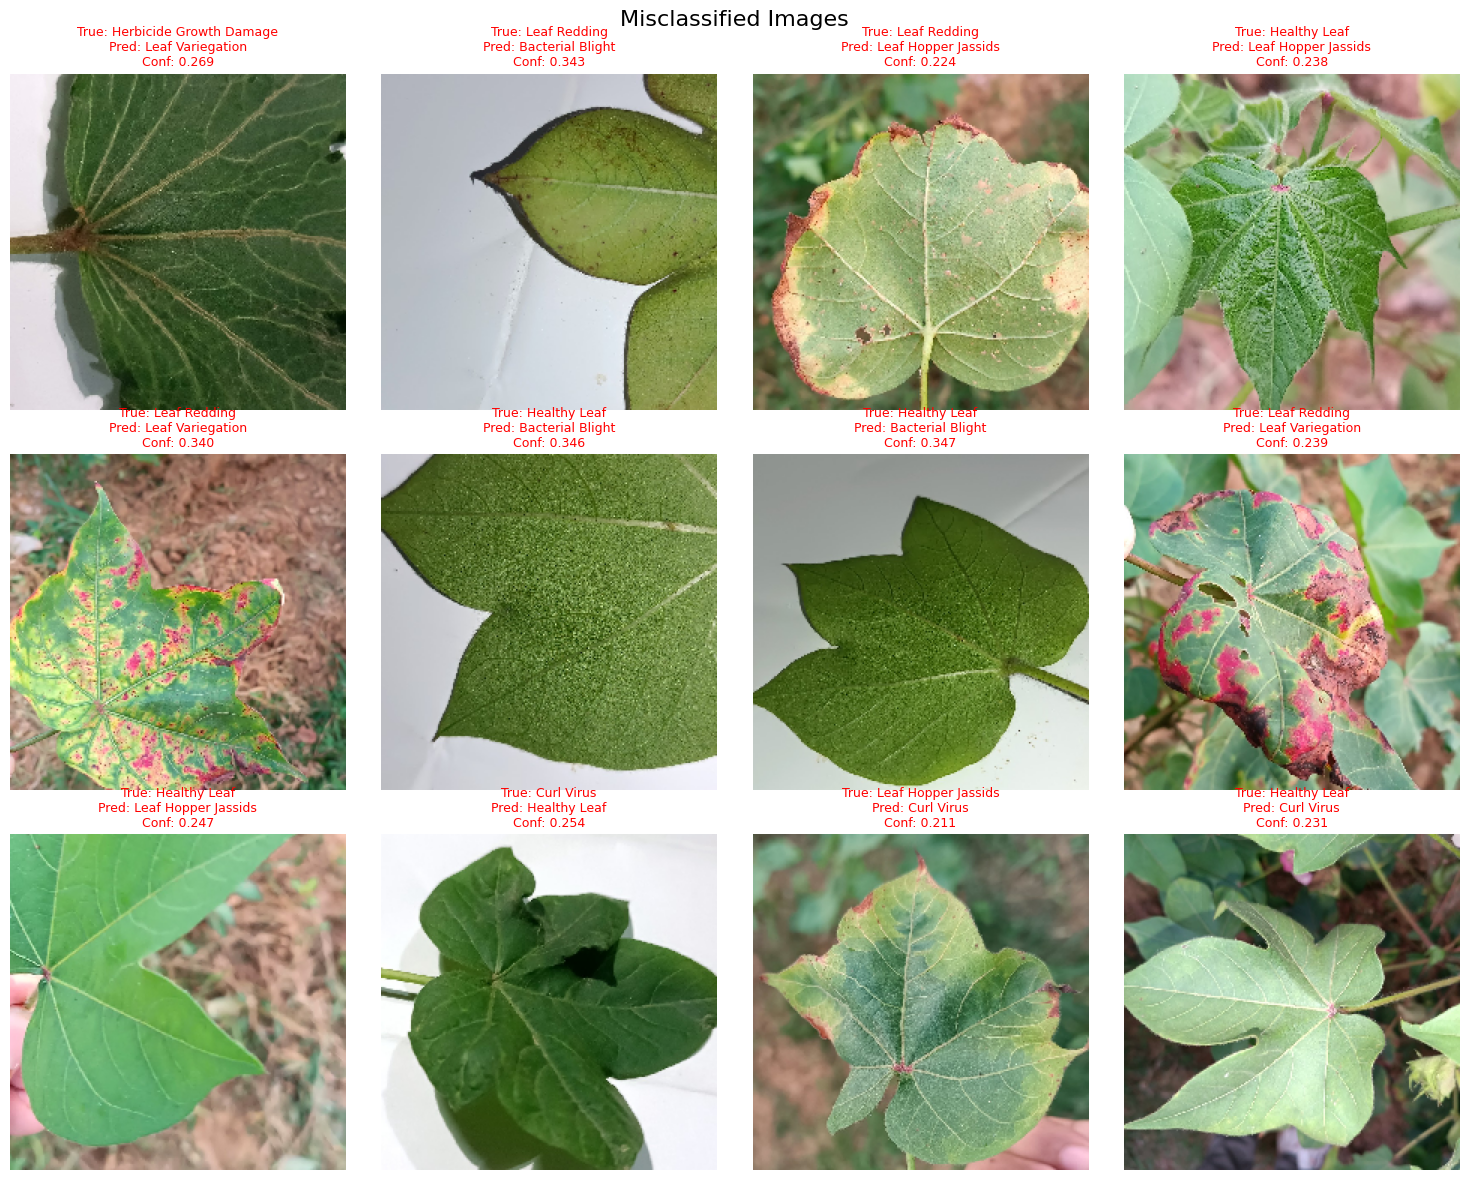


Error Rate by Class:
                     Class  Total Samples  Misclassifications  Error Rate
4      Leaf Hopper Jassids            225                 127   56.444444
1               Curl Virus            431                 227   52.668213
5             Leaf Redding            578                 283   48.961938
2             Healthy Leaf            257                 124   48.249027
0         Bacterial Blight            250                  86   34.400000
6         Leaf Variegation            116                   9    7.758621
3  Herbicide Growth Damage            280                  12    4.285714


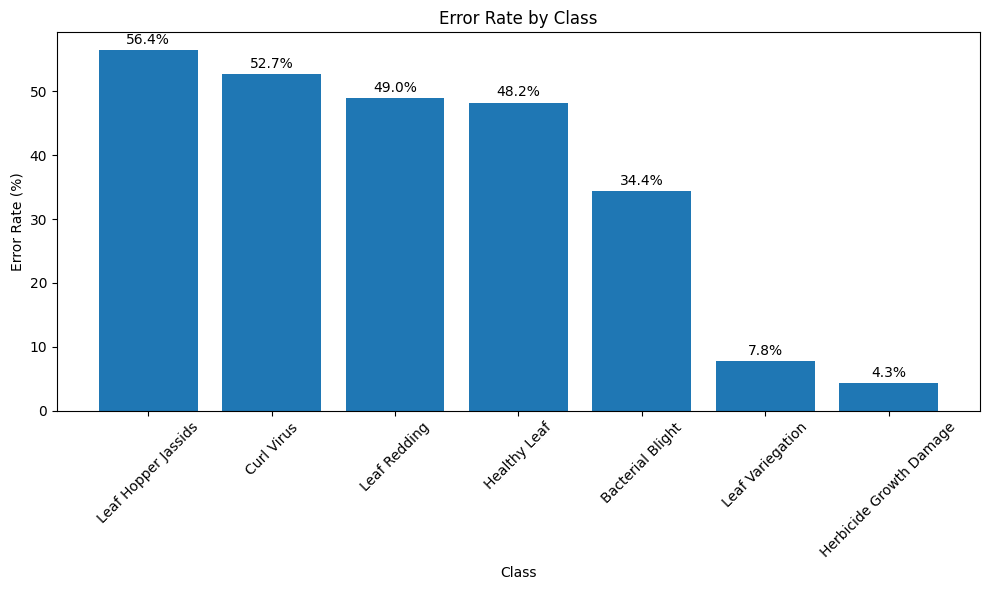


Most Common Misclassification Patterns:
             true_label      predicted_label  count
7            Curl Virus         Healthy Leaf    126
26         Leaf Redding     Bacterial Blight    119
14         Healthy Leaf  Leaf Hopper Jassids     68
27         Leaf Redding           Curl Virus     61
22  Leaf Hopper Jassids         Healthy Leaf     46
28         Leaf Redding         Healthy Leaf     46
9            Curl Virus  Leaf Hopper Jassids     37
30         Leaf Redding  Leaf Hopper Jassids     33
10           Curl Virus         Leaf Redding     32
1      Bacterial Blight         Healthy Leaf     32


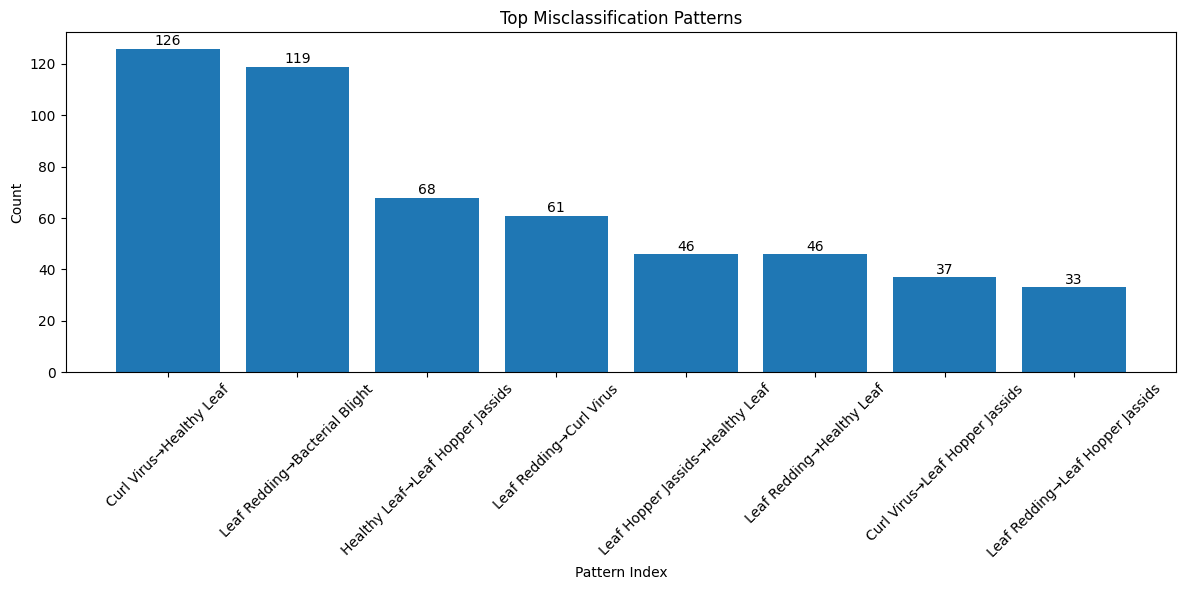

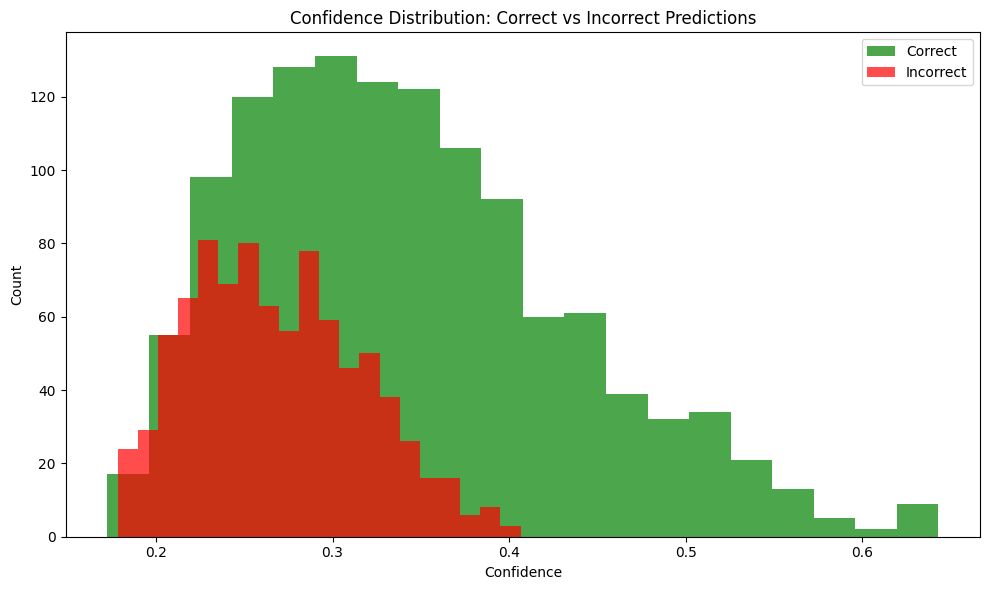


Confidence Statistics:
   correct      mean    median       std
0    False  0.268483  0.264611  0.048017
1     True  0.341782  0.328915  0.091490

High-confidence errors (confidence > 0.8): 0

Low-confidence correct predictions (confidence < 0.6): 1258

Error analysis completed. Check the generated images and report for insights.


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from tensorflow.keras.preprocessing import image
import seaborn as sns

# =====================================================================
# PATH CONFIGURATION MATCHING PREVIOUS STEP
# =====================================================================
base_dataset_path = "SAR-CLD-2024 A Comprehensive Dataset for Cotton Leaf Disease Detection"
original_path = os.path.join(base_dataset_path, "Original Dataset", "Original Dataset")

# Get predictions and true labels for the test set
test_generator.reset()
y_true = test_generator.classes
y_pred = np.argmax(model.predict(test_generator), axis=1)
y_probs = model.predict(test_generator)

# Get filenames for the test set
filenames = test_generator.filenames

# Create a DataFrame for analysis
results_df = pd.DataFrame({
    'filename': filenames,
    'true_label': [class_names[i] for i in y_true],
    'predicted_label': [class_names[i] for i in y_pred],
    'confidence': [np.max(y_probs[i]) for i in range(len(y_probs))],
    'correct': y_true == y_pred
})

# Filter misclassified images
misclassified_df = results_df[results_df['correct'] == False]

print(f"Total test samples: {len(results_df)}")
print(f"Misclassified samples: {len(misclassified_df)}")
print(f"Accuracy: {(len(results_df) - len(misclassified_df)) / len(results_df) * 100:.2f}%")


# 1. Display misclassified images with predictions and confidence
def display_misclassified_images(misclassified_df, num_samples=12):
    if len(misclassified_df) == 0:
        print("🎉 No misclassifications found to display!")
        return

    # Randomly select misclassified samples
    samples = misclassified_df.sample(min(num_samples, len(misclassified_df)))

    # Create a grid of images
    fig, axes = plt.subplots(3, 4, figsize=(15, 12))
    axes = axes.ravel()

    for i, (idx, row) in enumerate(samples.iterrows()):
        # UPDATED PATH: Pointing directly into the raw original test baseline folders
        img_path = os.path.join(original_path, row['filename'])
        img = image.load_img(img_path, target_size=(224, 224))

        axes[i].imshow(img)
        axes[i].set_title(f"True: {row['true_label']}\nPred: {row['predicted_label']}\nConf: {row['confidence']:.3f}",
                         fontsize=9, color='red')
        axes[i].axis('off')

    # Clear any leftover subplots if there are fewer errors than slots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.suptitle('Misclassified Images', fontsize=16)
    plt.tight_layout()
    plt.savefig('misclassified_images.png')
    plt.show()

display_misclassified_images(misclassified_df)


# 2. Analyze misclassifications by class
misclassification_by_class = results_df.groupby('true_label').agg({
    'correct': ['count', lambda x: sum(x == False)]
}).reset_index()
misclassification_by_class.columns = ['Class', 'Total Samples', 'Misclassifications']
misclassification_by_class['Error Rate'] = misclassification_by_class['Misclassifications'] / misclassification_by_class['Total Samples'] * 100
misclassification_by_class = misclassification_by_class.sort_values('Error Rate', ascending=False)

print("\nError Rate by Class:")
print(misclassification_by_class)

# Plot error rates by class
plt.figure(figsize=(10, 6))
bars = plt.bar(misclassification_by_class['Class'], misclassification_by_class['Error Rate'])
plt.title('Error Rate by Class')
plt.xlabel('Class')
plt.ylabel('Error Rate (%)')
plt.xticks(rotation=45)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.1f}%', ha='center', va='bottom')
plt.tight_layout()
plt.savefig('error_rate_by_class.png')
plt.show()


# 3. Most common misclassification patterns
misclassification_patterns = results_df[results_df['correct'] == False].groupby(
    ['true_label', 'predicted_label']).size().reset_index(name='count')
misclassification_patterns = misclassification_patterns.sort_values('count', ascending=False)

print("\nMost Common Misclassification Patterns:")
print(misclassification_patterns.head(10))

# Visualize common misclassification patterns
if len(misclassification_patterns) > 0:
    plt.figure(figsize=(12, 6))
    top_patterns = misclassification_patterns.head(8)
    bars = plt.bar(range(len(top_patterns)), top_patterns['count'])
    plt.title('Top Misclassification Patterns')
    plt.xlabel('Pattern Index')
    plt.ylabel('Count')
    plt.xticks(range(len(top_patterns)),
               [f"{row['true_label']}→{row['predicted_label']}" for _, row in top_patterns.iterrows()],
               rotation=45)

    # Add value labels on bars
    for bar, count in zip(bars, top_patterns['count']):
        plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
                 str(count), ha='center', va='bottom')
    plt.tight_layout()
    plt.savefig('top_misclassification_patterns.png')
    plt.show()


# 4. Analyze confidence of misclassifications vs correct classifications
plt.figure(figsize=(10, 6))
plt.hist(results_df[results_df['correct'] == True]['confidence'],
         alpha=0.7, label='Correct', bins=20, color='green')
plt.hist(results_df[results_df['correct'] == False]['confidence'],
         alpha=0.7, label='Incorrect', bins=20, color='red')
plt.title('Confidence Distribution: Correct vs Incorrect Predictions')
plt.xlabel('Confidence')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('confidence_distribution.png')
plt.show()


# 5. Analyze confidence statistics
confidence_stats = results_df.groupby('correct')['confidence'].agg(['mean', 'median', 'std']).reset_index()
print("\nConfidence Statistics:")
print(confidence_stats)


# 6. Examine high-confidence errors (potentially problematic cases)
high_confidence_errors = misclassified_df[misclassified_df['confidence'] > 0.8]
print(f"\nHigh-confidence errors (confidence > 0.8): {len(high_confidence_errors)}")
if len(high_confidence_errors) > 0:
    print("These cases represent potentially serious model errors:")
    for _, row in high_confidence_errors.iterrows():
        print(f"  {row['filename']}: True={row['true_label']}, Pred={row['predicted_label']}, Conf={row['confidence']:.3f}")


# 7. Examine low-confidence correct predictions (potentially lucky guesses)
low_confidence_correct = results_df[(results_df['correct'] == True) & (results_df['confidence'] < 0.6)]
print(f"\nLow-confidence correct predictions (confidence < 0.6): {len(low_confidence_correct)}")


# 8. Generate a detailed error analysis report
def generate_error_report(results_df, misclassification_patterns, misclassified_df):
    report = {
        'total_samples': len(results_df),
        'misclassified_samples': len(misclassified_df),
        'overall_accuracy': (len(results_df) - len(misclassified_df)) / len(results_df) * 100,
        'class_wise_error_rates': misclassification_by_class.to_dict('records'),
        'common_misclassification_patterns': misclassification_patterns.head(10).to_dict('records'),
        'average_confidence_correct': results_df[results_df['correct'] == True]['confidence'].mean(),
        'average_confidence_incorrect': results_df[results_df['correct'] == False]['confidence'].mean(),
        'high_confidence_errors': len(misclassified_df[misclassified_df['confidence'] > 0.8]),
        'low_confidence_correct': len(results_df[(results_df['correct'] == True) & (results_df['confidence'] < 0.6)])
    }

    # Save report
    with open('error_analysis_report.txt', 'w') as f:
        f.write("COTTON DISEASE CLASSIFICATION ERROR ANALYSIS REPORT\n")
        f.write("====================================================\n\n")
        f.write(f"Overall Accuracy: {report['overall_accuracy']:.2f}%\n")
        f.write(f"Misclassified Samples: {report['misclassified_samples']}/{report['total_samples']}\n\n")

        f.write("Class-wise Error Rates:\n")
        for item in report['class_wise_error_rates']:
            f.write(f"{item['Class']}: {item['Error Rate']:.2f}% ({item['Misclassifications']}/{item['Total Samples']})\n")

        f.write("\nMost Common Misclassification Patterns:\n")
        for item in report['common_misclassification_patterns']:
            f.write(f"{item['true_label']} -> {item['predicted_label']}: {item['count']} times\n")

        f.write(f"\nAverage Confidence for Correct Predictions: {report['average_confidence_correct']:.3f}\n")
        f.write(f"Average Confidence for Incorrect Predictions: {report['average_confidence_incorrect']:.3f}\n")
        f.write(f"High-confidence Errors (confidence > 0.8): {report['high_confidence_errors']}\n")
        f.write(f"Low-confidence Correct Predictions (confidence < 0.6): {report['low_confidence_correct']}\n")

    return report

error_report = generate_error_report(results_df, misclassification_patterns, misclassified_df)
print("\nError analysis completed. Check the generated images and report for insights.")

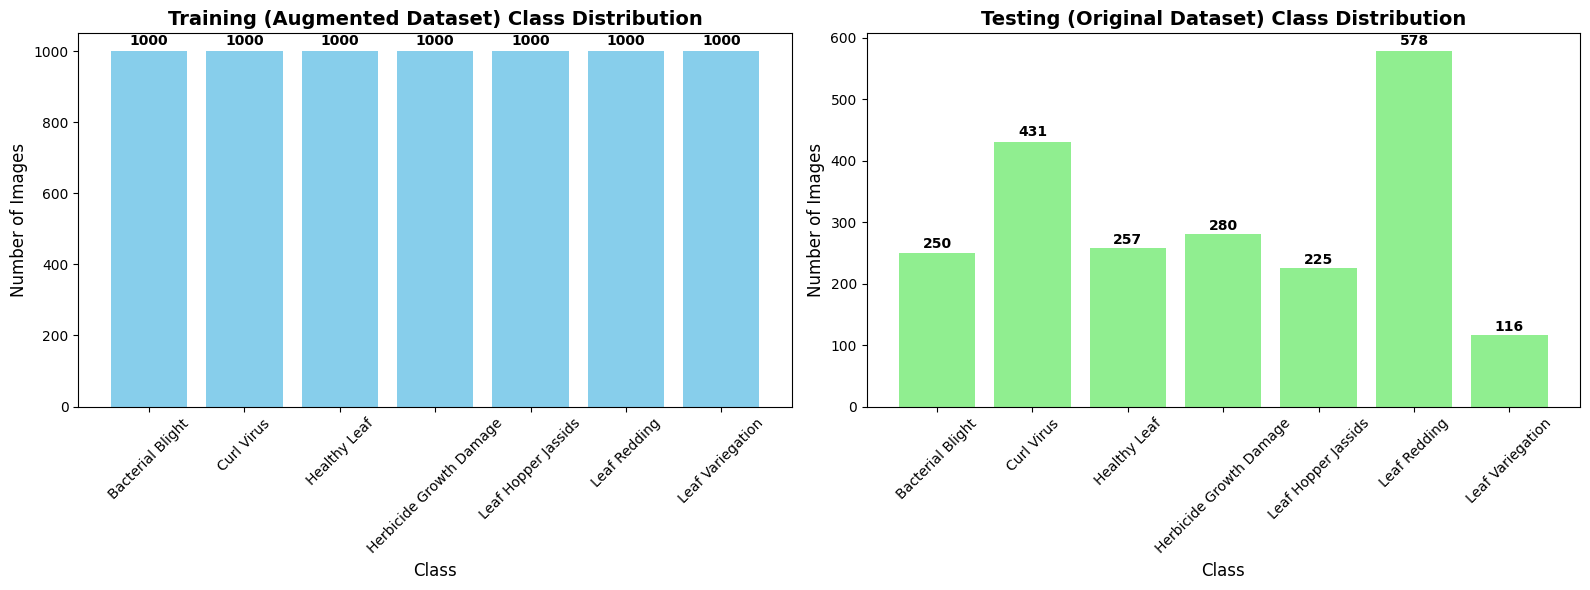

DATASET CLASS DISTRIBUTION SUMMARY

Training Dataset (Augmented Dataset) Class Distribution:
  Bacterial Blight: 1000 images
  Curl Virus: 1000 images
  Healthy Leaf: 1000 images
  Herbicide Growth Damage: 1000 images
  Leaf Hopper Jassids: 1000 images
  Leaf Redding: 1000 images
  Leaf Variegation: 1000 images

Testing Dataset (Original Dataset) Class Distribution:
  Bacterial Blight: 250 images
  Curl Virus: 431 images
  Healthy Leaf: 257 images
  Herbicide Growth Damage: 280 images
  Leaf Hopper Jassids: 225 images
  Leaf Redding: 578 images
  Leaf Variegation: 116 images

Total training images: 7000
Total testing images: 2137
Total images across both datasets: 9137

CLASS BALANCE ANALYSIS

Training Dataset Class Balance:
  Bacterial Blight: 1000 images (14.3%)
  Curl Virus: 1000 images (14.3%)
  Healthy Leaf: 1000 images (14.3%)
  Herbicide Growth Damage: 1000 images (14.3%)
  Leaf Hopper Jassids: 1000 images (14.3%)
  Leaf Redding: 1000 images (14.3%)
  Leaf Variegation: 1000 imag

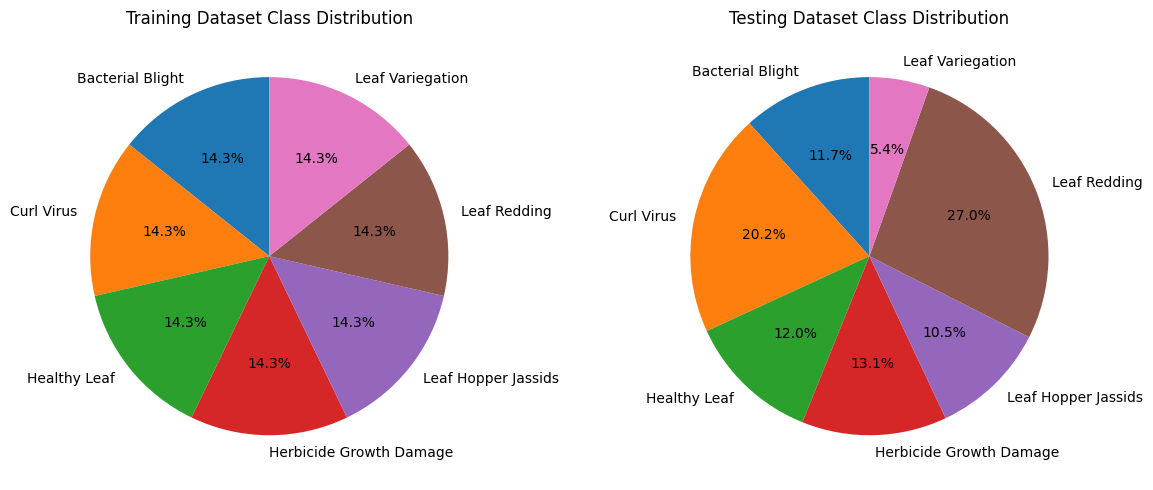


CLASS DISTRIBUTION COMPARISON TABLE
Class                Train Count  Test Count   Total      Train %    Test %    
--------------------------------------------------------------------------------
Bacterial Blight     1000         250          1250       14.3%      11.7%     
Curl Virus           1000         431          1431       14.3%      20.2%     
Healthy Leaf         1000         257          1257       14.3%      12.0%     
Herbicide Growth Damage 1000         280          1280       14.3%      13.1%     
Leaf Hopper Jassids  1000         225          1225       14.3%      10.5%     
Leaf Redding         1000         578          1578       14.3%      27.0%     
Leaf Variegation     1000         116          1116       14.3%      5.4%      


In [11]:
import matplotlib.pyplot as plt
import numpy as np
import os

# =====================================================================
# PATH CONFIGURATION MATCHING THE NEW DATASET STRUCTURE
# =====================================================================
base_dataset_path = "SAR-CLD-2024 A Comprehensive Dataset for Cotton Leaf Disease Detection"
augmented_path = os.path.join(base_dataset_path, "Augmented Dataset", "Augmented Dataset")
original_path = os.path.join(base_dataset_path, "Original Dataset", "Original Dataset")

# Define the exact 7 classes present in this dataset
class_names = [
    'Bacterial Blight',
    'Curl Virus',
    'Healthy Leaf',
    'Herbicide Growth Damage',
    'Leaf Hopper Jassids',
    'Leaf Redding',
    'Leaf Variegation'
]

# Get class distribution for training dataset (Augmented Dataset folder)
train_class_counts = {}
for class_name in class_names:
    class_dir = os.path.join(augmented_path, class_name)
    if os.path.exists(class_dir):
        train_class_counts[class_name] = len(os.listdir(class_dir))
    else:
        train_class_counts[class_name] = 0

# Get class distribution for testing dataset (Original Dataset folder)
test_class_counts = {}
for class_name in class_names:
    class_dir = os.path.join(original_path, class_name)
    if os.path.exists(class_dir):
        test_class_counts[class_name] = len(os.listdir(class_dir))
    else:
        test_class_counts[class_name] = 0

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot training dataset class distribution
bars1 = ax1.bar(train_class_counts.keys(), train_class_counts.values(), color='skyblue')
ax1.set_title('Training (Augmented Dataset) Class Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Class', fontsize=12)
ax1.set_ylabel('Number of Images', fontsize=12)
ax1.tick_params(axis='x', rotation=45)

# Add value labels on bars for training dataset
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + max(1, height * 0.01),
             f'{height}', ha='center', va='bottom', fontweight='bold')

# Plot testing dataset class distribution
bars2 = ax2.bar(test_class_counts.keys(), test_class_counts.values(), color='lightgreen')
ax2.set_title('Testing (Original Dataset) Class Distribution', fontsize=14, fontweight='bold')
ax2.set_xlabel('Class', fontsize=12)
ax2.set_ylabel('Number of Images', fontsize=12)
ax2.tick_params(axis='x', rotation=45)

# Add value labels on bars for testing dataset
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + max(1, height * 0.01),
             f'{height}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('dataset_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Print numerical summary
print("="*60)
print("DATASET CLASS DISTRIBUTION SUMMARY")
print("="*60)

print("\nTraining Dataset (Augmented Dataset) Class Distribution:")
for class_name, count in train_class_counts.items():
    print(f"  {class_name}: {count} images")

print("\nTesting Dataset (Original Dataset) Class Distribution:")
for class_name, count in test_class_counts.items():
    print(f"  {class_name}: {count} images")

total_train = sum(train_class_counts.values())
total_test = sum(test_class_counts.values())

print(f"\nTotal training images: {total_train}")
print(f"Total testing images: {total_test}")
print(f"Total images across both datasets: {total_train + total_test}")

# Calculate and display class balance percentages
print("\n" + "="*60)
print("CLASS BALANCE ANALYSIS")
print("="*60)

print("\nTraining Dataset Class Balance:")
for class_name, count in train_class_counts.items():
    percentage = (count / total_train) * 100 if total_train > 0 else 0
    print(f"  {class_name}: {count} images ({percentage:.1f}%)")

print("\nTesting Dataset Class Balance:")
for class_name, count in test_class_counts.items():
    percentage = (count / total_test) * 100 if total_test > 0 else 0
    print(f"  {class_name}: {count} images ({percentage:.1f}%)")

# Create a pie chart for dataset class distribution
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
if total_train > 0:
    plt.pie(train_class_counts.values(), labels=train_class_counts.keys(), autopct='%1.1f%%', startangle=90)
plt.title('Training Dataset Class Distribution')

plt.subplot(1, 2, 2)
if total_test > 0:
    plt.pie(test_class_counts.values(), labels=test_class_counts.keys(), autopct='%1.1f%%', startangle=90)
plt.title('Testing Dataset Class Distribution')

plt.tight_layout()
plt.savefig('dataset_class_pie_charts.png', dpi=300, bbox_inches='tight')
plt.show()

# Create a comparison table
comparison_data = []
for class_name in class_names:
    train_count = train_class_counts[class_name]
    test_count = test_class_counts[class_name]
    total_count = train_count + test_count
    train_percentage = (train_count / total_train) * 100 if total_train > 0 else 0
    test_percentage = (test_count / total_test) * 100 if total_test > 0 else 0
    comparison_data.append([class_name, train_count, test_count, total_count, f"{train_percentage:.1f}%", f"{test_percentage:.1f}%"])

# Display comparison table
print("\n" + "="*80)
print("CLASS DISTRIBUTION COMPARISON TABLE")
print("="*80)
print(f"{'Class':<20} {'Train Count':<12} {'Test Count':<12} {'Total':<10} {'Train %':<10} {'Test %':<10}")
print("-"*80)
for row in comparison_data:
    print(f"{row[0]:<20} {row[1]:<12} {row[2]:<12} {row[3]:<10} {row[4]:<10} {row[5]:<10}")